# 20251217

In [1]:
import siibra
from nilearn import plotting, image
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import plotly.graph_objects as go

import pyNN.neuron as sim
from pyNN import space
from pyNN.random import RandomDistribution, NumpyRNG
from pyNN.neuron import Projection, StaticSynapse, FixedNumberPreConnector
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

import scipy.signal as signal

import pandas as pd

[siibra:INFO] Version: 1.0.1-alpha.10
[siibra:WARNING] This is a development release. Use at your own risk.
[siibra:INFO] Please file bugs and issues at https://github.com/FZJ-INM1-BDA/siibra-python.
/home/tkmcg/neuron-env/lib/python3.12/site-packages/pyNN/neuron/__init__.py:14: UserWarning: mpi4py not available
  warnings.warn("mpi4py not available")


In [2]:
#class to get random points based on the STN in the Julich Brain CYTOARCHITECTURE
#new with space to for leads
class Julich_brain_cyto_random_point_generator:
    def __init__(self,parcellation, region, space, stimulating_electrode_position, encapsulation):
        #obtain the brain region required
        self.region = siibra.get_region(parcellation, region)
        
        #get the space required
        self.space = self.region.spaces.get(space)

    
        self.region_map = self.region.get_regional_map(space, maptype="statistical")
        self.NIfTI_region = self.region_map.fetch()
        self.region_data = self.NIfTI_region.get_fdata()
        self.affine = self.NIfTI_region.affine
        print(self.affine)


        # Flatten and mask out zero or invalid voxels
        self.region_data_flat = self.region_data.flatten()
        self.region_data_valid_probs = self.region_data_flat[self.region_data_flat > 0]

        #normalise the probabilities to work with random choice
        self.region_data_valid_probs /= self.region_data_valid_probs.sum()  

        ## Get voxel indices (i,j,k) of valid voxels
        self.region_data_indices = np.argwhere(self.region_data > 0)

        #stimulating electrode position and encapsulation
        self.stimulating_electrode_position = stimulating_electrode_position
        self.encapsulation = encapsulation

     
    def generate_positions(self, number_points):
        indices = np.random.choice(len(self.region_data_valid_probs), size = number_points, p=self.region_data_valid_probs)
        voxel_coords = self.region_data_indices[indices]

        offsets = np.random.normal(0, 0.33, size=(number_points, 3))
        voxel_points = voxel_coords + offsets

        ones = np.ones((number_points, 1))
        vox_hom = np.hstack([voxel_points, ones])          # (N,4)
        world_points = (self.affine @ vox_hom.T).T[:, :3]

        #remove points from the encapsulation layer
        x_min, x_max, y_min, y_max = self.stimulating_electrode_position[0]-self.encapsulation, self.stimulating_electrode_position[0]+self.encapsulation, self.stimulating_electrode_position[1]-self.encapsulation, self.stimulating_electrode_position[1]+self.encapsulation

        mask = ~(
        (x_min < world_points[:, 0]) & (world_points[:, 0] < x_max) &
        (y_min < world_points[:, 1]) & (world_points[:, 1] < y_max))

        if mask.sum() < number_points:
            missing = number_points - mask.sum()
            extra = self.generate_positions(missing)
            world_points = np.vstack([world_points[mask], extra])
        else:
            world_points = world_points[mask][:number_points]
    
        return world_points

In [3]:
voltage_file = pd.read_csv(
    "../2202_Mesh0_E1_270625_BSGrid_V.txt",
    sep=r"\s+",
    header=None,
    names=["x", "y", "z", "V"]
)


x_voltage_coordinates = voltage_file['x'].values
y_voltage_coordinates = voltage_file['y'].values
z_voltage_coordinates = voltage_file['z'].values
voltages = voltage_file['V'].values


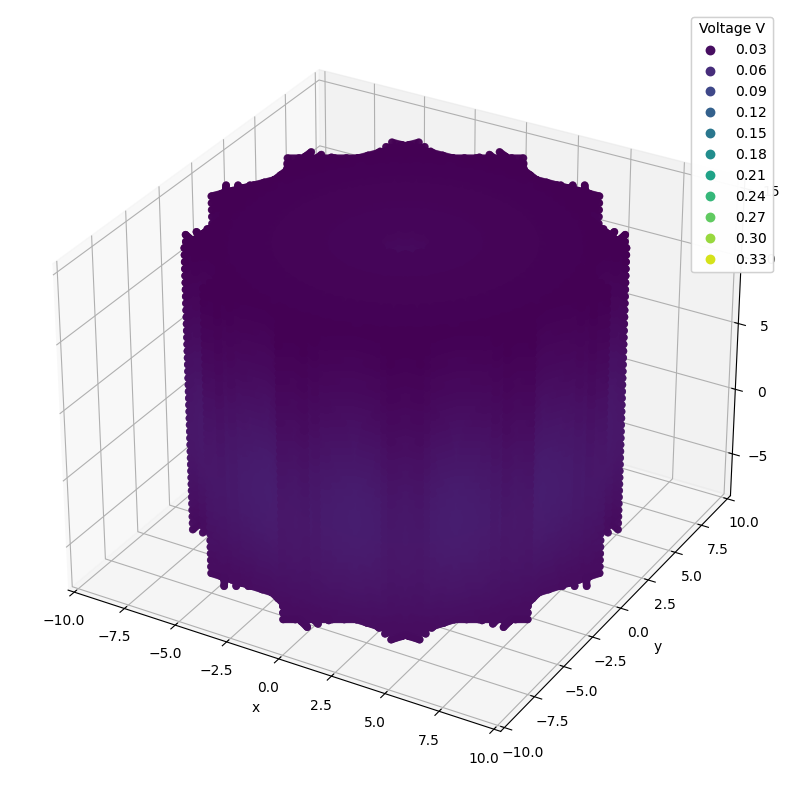

In [4]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('x')
ax.set_zlabel('z')
ax.set_ylabel('y')

scatter = ax.scatter(x_voltage_coordinates, y_voltage_coordinates, z_voltage_coordinates, c = voltages)

legend1 = ax.legend(*scatter.legend_elements(), loc="upper right", title="Voltage V")
ax.add_artist(legend1)

plt.show()

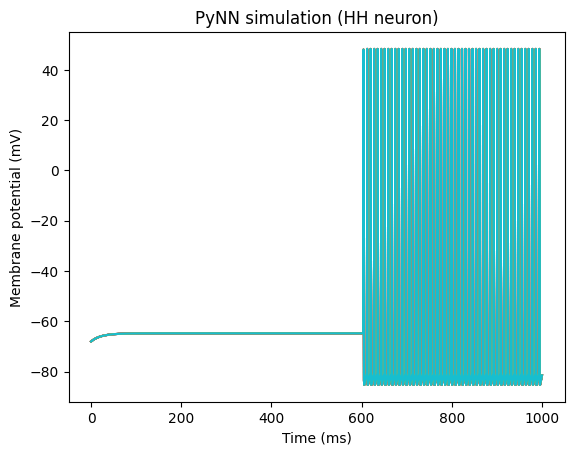

In [5]:
##### Add in the STN neurons and change the geometry to match the coupling project with DC current ####
import pyNN.neuron as sim
import matplotlib.pyplot as plt
from pyNN import space
from pyNN.random import RandomDistribution, NumpyRNG
import numpy as np
from pyNN.neuron import Projection, StaticSynapse, FixedNumberPreConnector
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

v_init = -68
rng_seed = 856

############ Setup the simulation##########
sim.setup(timestep=0.01)

###########Set up the structure ############
cortical_space = space.RandomStructure(boundary=space.Cuboid(8, 8, 8))
STN_space = space.RandomStructure(boundary=space.Cuboid(4,4,12))

###########set up the neuron type##############
cortical_type = sim.HH_cond_exp()
STN_type = sim.HH_cond_exp()

########## create a population of neurons ###############
cortical_pop = sim.Population(100, cortical_type, structure=cortical_space, initial_values={'v': v_init}, label="Cortical neurons")
STN_pop = sim.Population(100, STN_type, structure=STN_space, initial_values={'v': v_init}, label="STN neurons")

########  offset the STN neurons ############
for STN_cell in STN_pop:
    STN_cell.position[2] = STN_cell.position[2] + 6000
'''
##### check no neurons in the no go area####
# stn neurons
for STN_cell in STN_pop:
    while (
        (np.abs(STN_cell.position[0]) > 4000)
        or ((np.abs(STN_cell.position[1]) > 4000))
        or (np.abs(STN_cell.position[2]) > 12000)
    ) or (
        (-150 < STN_cell.position[0] < 150)
            and (-317.5 < STN_cell.position[2] < 317.5)
        ):
            STN_cell.position = STN_space.generate_positions(1).flatten()

for Cortical_cell in cortical_pop:
    while (
        (np.abs(Cortical_cell.position[0]) > 8000)
        or ((np.abs(Cortical_cell.position[1]) > 8000))
         or ((np.abs(Cortical_cell.position[2]) > 8000))
        ) or (
            (-150 < Cortical_cell.position[0] < 150)
            and (-67.5 < Cortical_cell.position[2] < 567.5) #z limit -317.5 < z < 317.5 but offset by +250
        ):
        Cortical_cell.position = cortical_space.generate_positions(1).flatten()
'''
############ set up the current ##############
start = 600
stop = 1000
cortical_pop.inject(sim.DCSource(start=start, stop=stop, amplitude=1))

############# make the connections ############
syn_CorticalCollateralSTN = StaticSynapse(weight=0.12, delay=1)

prj_CorticalSTN = Projection(
    cortical_pop,
    STN_pop,
    FixedNumberPreConnector(n=5, allow_self_connections=False),
    syn_CorticalCollateralSTN,
    source="collateral(0.5)",
    receptor_type="excitatory",
)

######## Record membrane potential from the STN neurons #############
#cortical_pop.record('v')

STN_pop.sample(10).record('v')

######### Run the simulation ###########
sim.run(1000)

############ Get and plot data ############
data = STN_pop.get_data().segments[0]
vm = data.filter(name="v")[0]

plt.plot(vm.times, vm)
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("PyNN simulation (HH neuron)")
plt.show()

####### Clean up ###########
sim.end()

In [6]:
points = np.array([x_voltage_coordinates,y_voltage_coordinates,z_voltage_coordinates]).T
Vint = LinearNDInterpolator(points, voltages)

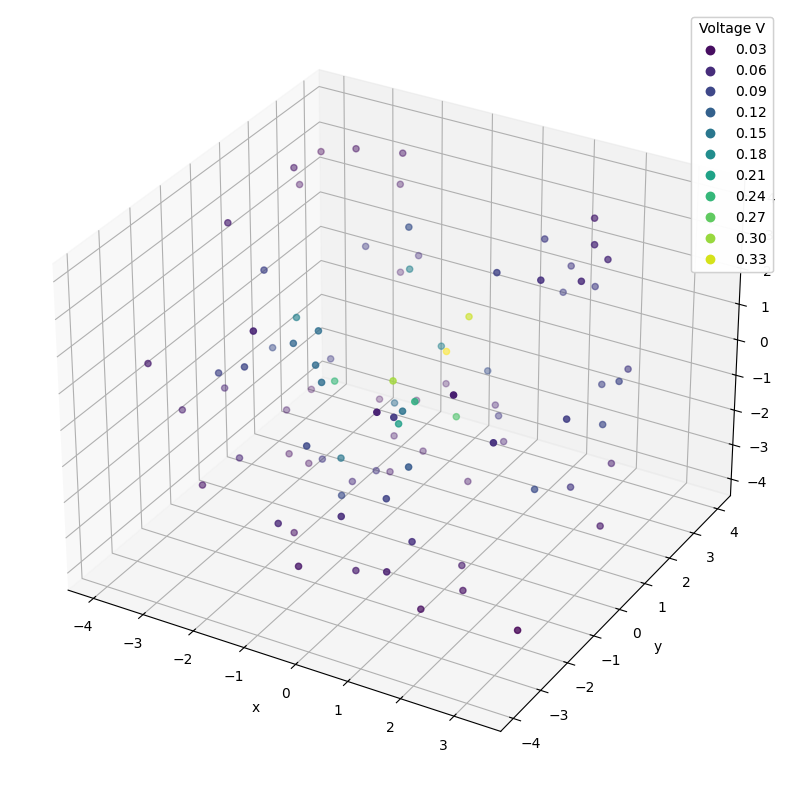

In [7]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('x')
ax.set_zlabel('z')
ax.set_ylabel('y')

#interpolate the values for the ctx neurons
x_points_ctx = cortical_pop.positions[0]
y_points_ctx = cortical_pop.positions[1]
z_points_ctx = cortical_pop.positions[2]
interpolated_values_ctx = Vint(np.column_stack((x_points_ctx, y_points_ctx, z_points_ctx)))
ax.scatter(x_points_ctx, y_points_ctx, z_points_ctx, c=interpolated_values_ctx)

#interpolate the values for the stn neurons
x_points_stn = STN_pop.positions[0]
y_points_stn = STN_pop.positions[1]
z_points_stn = STN_pop.positions[2]
interpolated_values_stn = Vint(np.column_stack((x_points_stn, y_points_stn, z_points_stn)))
ax.scatter(x_points_stn, z_points_stn, y_points_stn, c=interpolated_values_stn)

legend1 = ax.legend(*scatter.legend_elements(), loc="upper right", title="Voltage V")
ax.add_artist(legend1)


plt.show()


# 20260105

In [1]:
from neuron import h

soma = h.Section(name='soma')
collateral = h.Section(name='collateral')
collateral.connect(soma(1), 0)

collateral.insert('extracellular')

seg = collateral(0.5)
seg._ref_e_extracellular[0] = 1

#print(seg.e_extracellular[0])          # value
print(seg._ref_e_extracellular[0])     # reference (pointer)

1.0


In [2]:
from neuron import h, gui

# Create a single compartment (soma)
soma = h.Section(name='soma')
soma.L = 20  # length in µm
soma.diam = 20  # diameter in µm

# Insert passive properties
soma.insert('pas')
soma.g_pas = 0.001
soma.e_pas = -65  # resting potential in mV

# Add extracellular mechanism
soma.insert('extracellular')

# Set extracellular potential at segment 0
soma(0.5).e_extracellular = 5  # mV

# Record intracellular voltage and vext[0]
v_vec = h.Vector()
vext_vec = h.Vector()
time_vec = h.Vector()

v_vec.record(soma(0.5)._ref_v)           # intracellular voltage
vext_vec.record(soma(0.5)._ref_vext[0])  # extracellular potential
time_vec.record(h._ref_t)                # time

# Stimulate soma with current
stim = h.IClamp(soma(0.5))
stim.delay = 5
stim.dur = 50
stim.amp = 0.1  # nA

# Run simulation
h.tstop = 60
h.run()

# Print values at t=10 ms
print("Simulating voltage v:", soma(0.5).e_extracellular)
print("Intracellular voltage v:", v_vec[5])
print("Extracellular potential vext[0]:", vext_vec[5])
print("Membrane potential including extracellular:", v_vec[5] + vext_vec[5])

Simulating voltage v: 5.0
Intracellular voltage v: -64.9999999999999
Extracellular potential vext[0]: 5.0
Membrane potential including extracellular: -59.9999999999999


In [3]:
from nrnutils import Mechanism, Section

class SimpleNeuron(object):

    def __init__(self, **parameters):
        hh = Mechanism('hh', gl=parameters['g_leak'], el=-65, gnabar=parameters['gnabar'], gkbar=parameters['gkbar'])
        self.soma = Section(L=30, diam=30, mechanisms=[hh])
        self.soma.add_synapse('ampa', 'Exp2Syn', e=0.0, tau1=0.1, tau2=5.0)
        self.initial_values = {"v": -65.0}

        self.soma.insert("extracellular")

        # needed for PyNN
        self.source_section = self.soma
        self.source = self.soma(0.5)._ref_v
        self.parameter_names = ('g_leak', 'gnabar', 'gkbar')
        self.traces = {}
        self.recording_time = False
        

In [4]:
from pyNN.neuron import NativeCellType

class SimpleNeuronType(NativeCellType):
    default_parameters = {'g_leak': 0.0002, 'gkbar': 0.036, 'gnabar': 0.12}
    default_initial_values = {'v': -65.0}
    recordable = ['soma(0.5).v', 'soma(0.5).ina']
    units = {'soma(0.5).v' : 'mV', 'soma(0.5).ina': 'nA'}
    receptor_types = ['soma.ampa']
    model = SimpleNeuron

/home/tkmcg/neuron-env/lib/python3.12/site-packages/pyNN/neuron/__init__.py:14: UserWarning: mpi4py not available
  warnings.warn("mpi4py not available")


In [5]:
print(SimpleNeuronType.recordable)

['soma(0.5).v', 'soma(0.5).ina']


## 20260106 

In [18]:
import pandas as pd
voltage_file = pd.read_csv(
    "../2202_Mesh0_E1_270625_BSGrid_V.txt",
    sep=r"\s+",
    header=None,
    names=["x", "y", "z", "V"]
)

print(voltage_file.to_numpy())

[[-5.          0.         -6.75        0.0371284 ]
 [-5.          0.5        -6.75        0.03705937]
 [-5.          1.         -6.75        0.03685417]
 ...
 [ 7.58012702  3.12916512 22.25               nan]
 [ 7.83012702  3.56217783 22.25               nan]
 [ 8.08012702  3.99519053 22.25               nan]]


In [83]:
efield = np.array([[5, 0, 0,46],[1, 0, 0,278], [9, 0, 0, 8], [0, 0, 0, 35], [4, 0, 0, 59], [3, 0, 0,86], [6, 0, 0,562], [8, 0, 0, 34], [2, 0, 0, 654], [7, 0, 0,456]])
x = np.array([3,0,0]) 

test = (x == efield[:, :-1])
indices = np.where(np.all(test, axis=1))[0]

print(indices)


[5]


In [84]:
##### Add in the STN neurons and change the geometry to match the coupling project with DC current ####
import pyNN.neuron as sim
import matplotlib.pyplot as plt
from pyNN import space
from pyNN.random import RandomDistribution, NumpyRNG
import numpy as np
from pyNN.neuron import Projection, StaticSynapse, FixedNumberPreConnector
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
from neuron import h, gui

v_init = -68
rng_seed = 856

############ Setup the simulation##########
sim.setup(timestep=0.01)

###########Set up the structure ############
cortical_space = space.RandomStructure(boundary=space.Cuboid(8, 8, 8))

########## create a population of neurons ###############
p1 = sim.Population(10, SimpleNeuronType())

for cell in p1:
    test = (cell.position == efield[:, :-1])
    indices = np.where(np.all(test, axis=1))[0]
    indices = int(indices[0])
    cell.e_extracellular = efield[indices, 3]
    print(cell, cell.position, indices, cell.e_extracellular)


0 [0. 0. 0.] 3 35
1 [1. 0. 0.] 1 278
2 [2. 0. 0.] 8 654
3 [3. 0. 0.] 5 86
4 [4. 0. 0.] 4 59
5 [5. 0. 0.] 0 46
6 [6. 0. 0.] 6 562
7 [7. 0. 0.] 9 456
8 [8. 0. 0.] 7 34
9 [9. 0. 0.] 2 8


## Putting it all together

In [89]:
##### Add in the STN neurons and change the geometry to match the coupling project with DC current ####
import pyNN.neuron as sim
import matplotlib.pyplot as plt
from pyNN import space
from pyNN.random import RandomDistribution, NumpyRNG
import numpy as np
from pyNN.neuron import Projection, StaticSynapse, FixedNumberPreConnector
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

v_init = -68
rng_seed = 856

############ Setup the simulation##########
sim.setup(timestep=0.01)

###########Set up the structure ############
cortical_space = space.RandomStructure(boundary=space.Cuboid(8, 8, 8))
STN_space = space.RandomStructure(boundary=space.Cuboid(4,4,12))

########## create a population of neurons ###############
cortical_neurons = sim.Population(100, SimpleNeuronType(), structure=cortical_space)


In [90]:
voltage_file = pd.read_csv(
    "../2202_Mesh0_E1_270625_BSGrid_V.txt",
    sep=r"\s+",
    header=None,
    names=["x", "y", "z", "V"]
)


x_voltage_coordinates = voltage_file['x'].values
y_voltage_coordinates = voltage_file['y'].values
z_voltage_coordinates = voltage_file['z'].values
voltages = voltage_file['V'].values

In [91]:
points = np.array([x_voltage_coordinates,y_voltage_coordinates,z_voltage_coordinates]).T
Vint = LinearNDInterpolator(points, voltages)

In [93]:
x_points_ctx = cortical_neurons.positions[0]
y_points_ctx = cortical_neurons.positions[1]
z_points_ctx = cortical_neurons.positions[2]
interpolated_values_ctx = Vint(np.column_stack((x_points_ctx, y_points_ctx, z_points_ctx)))

In [100]:
efield = np.column_stack((x_points_ctx, y_points_ctx, z_points_ctx,interpolated_values_ctx))
print(efield)

[[-0.25022323  2.42793348 -1.2674373   0.12022241]
 [ 1.30286041  2.77130984 -1.3613244   0.10111129]
 [ 2.90637945  3.0798039  -2.91623246  0.06441708]
 [ 0.97145219  2.84820923 -0.96103634  0.10910039]
 [ 3.40812196  3.79981791  0.22132765  0.07069803]
 [-1.93806567  1.24712638 -0.31019184  0.15182603]
 [ 1.21275599 -2.28120129  1.31055041  0.14462604]
 [-3.065984   -1.00230446 -3.72670051  0.06560177]
 [-1.7296764  -3.66728434  1.24617733  0.09065499]
 [-2.82226424 -0.62434609 -3.17516034  0.07535713]
 [-0.39403585  2.82816718 -0.34759365  0.12440585]
 [-2.99203079  2.4781133  -3.49809544  0.0625512 ]
 [ 3.92083546 -1.64641649 -2.84325916  0.06488478]
 [-1.05115154  3.52997796 -1.20761084  0.0891267 ]
 [-2.43042928 -1.70781548 -2.39227792  0.08598662]
 [-2.91948403  2.5619966  -0.77414931  0.08910269]
 [ 3.17604066 -1.87110036 -2.56589345  0.07388759]
 [ 2.5398968  -2.62644888 -1.13669743  0.09050441]
 [-0.73144385 -3.42190664  3.97692217  0.07542938]
 [ 0.01097905 -0.16395711  3.34

In [99]:
for cell in cortical_neurons:
    test = (cell.position == efield[:, :-1])
    indices = np.where(np.all(test, axis=1))[0]
    indices = int(indices[0])
    cell.e_extracellular = efield[indices, 3]
    print(cell, cell.position, indices, cell.e_extracellular)

0 [-0.25022323  2.42793348 -1.2674373 ] 0 0.12022240800908862
1 [ 1.30286041  2.77130984 -1.3613244 ] 1 0.10111129131835489
2 [ 2.90637945  3.0798039  -2.91623246] 2 0.06441708405186833
3 [ 0.97145219  2.84820923 -0.96103634] 3 0.10910038720969019
4 [3.40812196 3.79981791 0.22132765] 4 0.07069803146554696
5 [-1.93806567  1.24712638 -0.31019184] 5 0.1518260336924071
6 [ 1.21275599 -2.28120129  1.31055041] 6 0.14462604003269253
7 [-3.065984   -1.00230446 -3.72670051] 7 0.06560177380139529
8 [-1.7296764  -3.66728434  1.24617733] 8 0.09065499438474582
9 [-2.82226424 -0.62434609 -3.17516034] 9 0.07535712737725904
10 [-0.39403585  2.82816718 -0.34759365] 10 0.12440585063786225
11 [-2.99203079  2.4781133  -3.49809544] 11 0.06255120204407288
12 [ 3.92083546 -1.64641649 -2.84325916] 12 0.06488477737537132
13 [-1.05115154  3.52997796 -1.20761084] 13 0.08912670171053741
14 [-2.43042928 -1.70781548 -2.39227792] 14 0.08598661705151937
15 [-2.91948403  2.5619966  -0.77414931] 15 0.08910268684191247
